In [36]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

In [37]:
from google.colab import files

uploaded = files.upload()

Saving insurance_data.csv to insurance_data (1).csv


In [38]:
df_insurance = pd.read_csv("insurance_data.csv")
df_insurance.head()

,age,bought_insurance
0,22,0
1,25,0
2,47,1
3,52,0
4,46,1


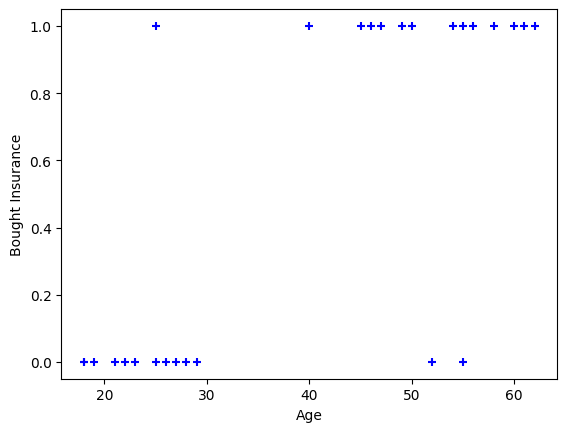

In [41]:
plt.scatter(df_insurance.age, df_insurance.bought_insurance, marker='+', color="blue")
plt.xlabel("Age")
plt.ylabel("Bought Insurance")
plt.show()

In [42]:
from sklearn.model_selection import train_test_split

In [43]:
X_train, X_test, y_train, y_test = train_test_split(df_insurance[['age']],df_insurance.bought_insurance,train_size=0.8)

In [44]:
X_test

,age
21,26
20,21
14,49
9,61
8,62
4,46


In [45]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [49]:
model.fit(X_train, y_train)
# z = wx + b
# w = coefficient
# b = intercept
# x = age
# sigmoid function, P = 1/ (1+e^-z)

LogisticRegression()

In [51]:
y_predicted = model.predict(X_test)

In [52]:
y_predicted

array([0, 0, 1, 1, 1, 1])

In [53]:
model.predict_proba(X_test)

array([[0.83266091, 0.16733909],
       [0.89876696, 0.10123304],
       [0.25754465, 0.74245535],
       [0.07955885, 0.92044115],
       [0.07148128, 0.92851872],
       [0.32929552, 0.67070448]])

In [54]:
model.score(X_test,y_test)

1.0

In [55]:
y_test

,bought_insurance
21,0
20,0
14,1
9,1
8,1
4,1


In [56]:
model.coef_ #w

array([[0.11579886]])

In [57]:
model.intercept_ #b

array([-4.61537473])

In [58]:
#sigmoid function
import math
def sigmoid(x):
  return 1 / (1 + math.exp(-x))

In [59]:
def prediction_function(age):
    z = 0.116 * age - 4.616 # 0.11579886 ~ 0.116 and -4.61537473 ~ -4.616
    y = sigmoid(z)
    return y

In [60]:
age = 35
prediction_function(age)

0.36447348673568986

In [61]:
age = 43
prediction_function(age)

0.5919421603995896

In [62]:
x_values = np.linspace(
    df_insurance.age.min(),
    df_insurance.age.max(),
    100
).reshape(-1, 1)


In [63]:
y_values = model.predict_proba(x_values)[:, 1]


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


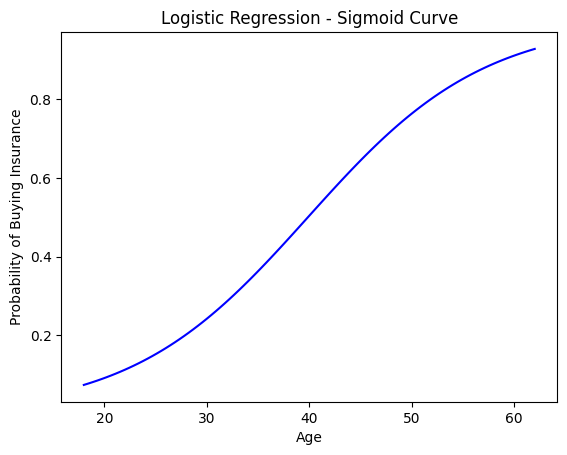

In [65]:
plt.plot(
    x_values,
    y_values,
    color='blue'
)
plt.xlabel("Age")
plt.ylabel("Probability of Buying Insurance")
plt.title("Logistic Regression - Sigmoid Curve")
plt.show()